In [ ]:
# imports
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet


In [2]:
"""
ONLY RUN THIS ONCE PER SESSION
    - Loading in Data so dont want to make too many requests to the API
    - Use df to see whats loaded 
    - This was used to make the CSV file for the project, uncomment if you need additional data

BASE = "https://pokeapi.co/api/v2"

# Making the request
resp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})
species_list = resp.json()["results"]

rows = []
for s in species_list:
    data = requests.get(s["url"]).json()
    time.sleep(0.1)
    # Grabbing the pokedex entry 
    entry = next(
        (f["flavor_text"].replace("\n", " ").replace("\f", " ")
         for f in data["flavor_text_entries"]
         if f["language"]["name"] == "en"),
        None,
    )

    genus = next(
        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),
        None,
    )

    type_1, type_2 = None, None
    try:
        pk = requests.get(f"{BASE}/pokemon/{s['name']}").json()
        types = sorted(pk["types"], key=lambda t: t["slot"])
        type_1 = types[0]["type"]["name"] if len(types) > 0 else None
        type_2 = types[1]["type"]["name"] if len(types) > 1 else None
    except Exception:
        pass

    rows.append({
        "id": data["id"],
        "name": data["name"],
        "genus": genus,
        "type_1": type_1,
        "type_2": type_2,
        "color": data["color"]["name"],
        "generation": data["generation"]["name"],
        "pokedex_entry": entry,
    })

df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
print(df.head())
df.to_csv("pokedex.csv", index=False)
"""

'\nONLY RUN THIS ONCE PER SESSION\n    - Loading in Data so dont want to make too many requests to the API\n    - Use df to see whats loaded \n    - This was used to make the CSV file for the project, uncomment if you need additional data\n\nBASE = "https://pokeapi.co/api/v2"\n\n# Making the request\nresp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})\nspecies_list = resp.json()["results"]\n\nrows = []\nfor s in species_list:\n    data = requests.get(s["url"]).json()\n    time.sleep(0.1)\n    # Grabbing the pokedex entry \n    entry = next(\n        (f["flavor_text"].replace("\n", " ").replace("\x0c", " ")\n         for f in data["flavor_text_entries"]\n         if f["language"]["name"] == "en"),\n        None,\n    )\n\n    genus = next(\n        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),\n        None,\n    )\n\n    type_1, type_2 = None, None\n    try:\n        pk = requests.get(f"{BASE}/pokemon/{s[\'name\']}").json()\n        types = s

In [3]:
csv_files = [
    "../DATA/pokedex.csv",
]

df = pd.read_csv(csv_files[0])
df


,id,name,genus,type_1,type_2,color,generation,pokedex_entry
0,1,bulbasaur,Seed Pokémon,grass,poison,green,generation-i,A strange seed was planted on its back at birt...
1,2,ivysaur,Seed Pokémon,grass,poison,green,generation-i,"When the bulb on its back grows large, it appe..."
2,3,venusaur,Seed Pokémon,grass,poison,green,generation-i,The plant blooms when it is absorbing solar en...
3,4,charmander,Lizard Pokémon,fire,NaN,red,generation-i,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,Flame Pokémon,fire,NaN,red,generation-i,"When it swings its burning tail, it elevates t..."
...,...,...,...,...,...,...,...,...
1020,1021,raging-bolt,Paradox Pokémon,electric,dragon,yellow,generation-ix,It's said to incinerate everything around it w...
1021,1022,iron-boulder,Paradox Pokémon,rock,psychic,gray,generation-ix,It resembles a Pokémon described in a dubious ...
1022,1023,iron-crown,Paradox Pokémon,steel,psychic,blue,generation-ix,It resembles a mysterious object introduced in...
1023,1024,terapagos,Tera Pokémon,normal,NaN,blue,generation-ix,Terapagos protects itself using its power to t...


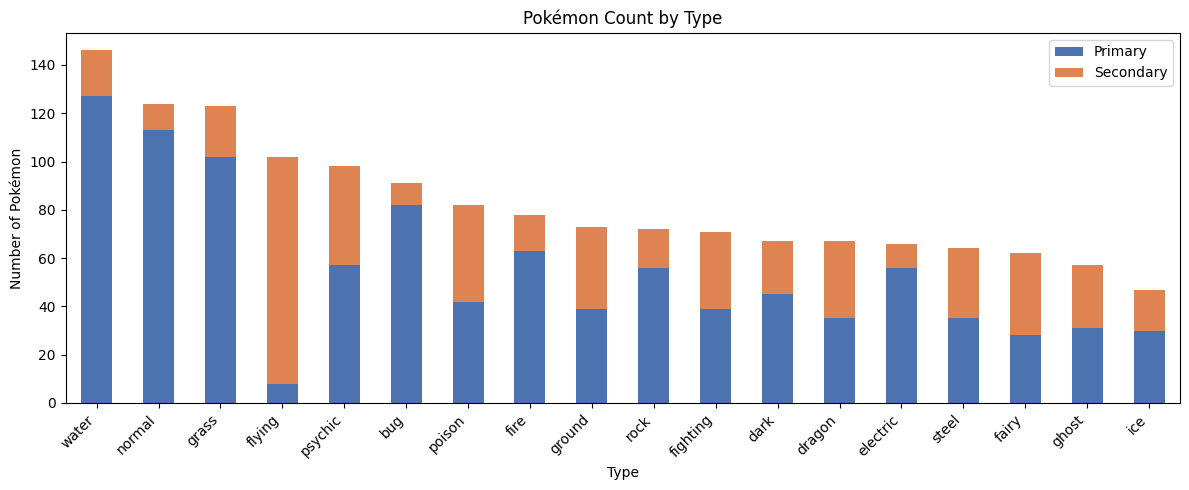

Missing type_1: 37


In [4]:
type_counts = pd.DataFrame({
    "Primary": df["type_1"].value_counts(),
    "Secondary": df["type_2"].value_counts(),
}).fillna(0)

type_counts = type_counts.loc[
    type_counts.sum(axis=1).sort_values(ascending=False).index
]

ax = type_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#4C72B0", "#DD8452"]
)

ax.set_title("Pokémon Count by Type")
ax.set_xlabel("Type")
ax.set_ylabel("Number of Pokémon")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save the plot
plt.savefig("../OUTPUT/pokemonTypeCounts.png", dpi=300, bbox_inches="tight")

plt.show()

print("Missing type_1:", df["type_1"].isna().sum())

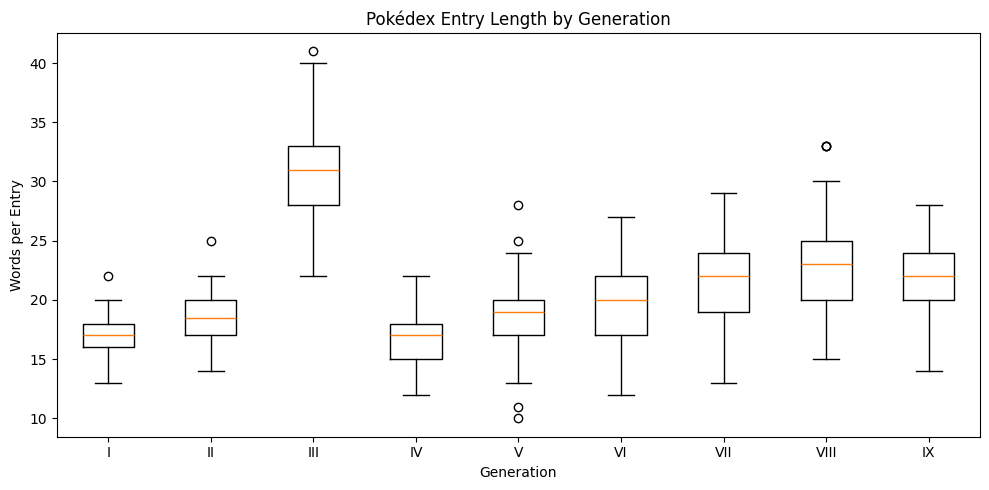

In [5]:
entries = df.dropna(subset=["pokedex_entry"]).copy()
entries["entry_words"] = entries["pokedex_entry"].str.split().str.len()

# Order generations
gen_order = entries.groupby("generation")["id"].min().sort_values().index
labels = [g.split("-")[1].upper() for g in gen_order]
data = [entries.loc[entries["generation"] == g, "entry_words"] for g in gen_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data)
ax.set_xticklabels(labels)
ax.set_title("Pokédex Entry Length by Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Words per Entry")
plt.tight_layout()
plt.savefig("../OUTPUT/pokemonEntryLength.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
def l2_normalize(X):
    """Scale each row to unit length """
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms


def cosine_distances(X):
    d = np.clip(pdist(X, metric="cosine"), 0.0, 2.0)
    return d, squareform(d)


def load_matrix(path, label_col):
    df_clean = pd.read_csv(path)
    if label_col in df_clean.columns:
        df_clean = df_clean.set_index(label_col)
    else:                                  # fall back to first column
        df_clean = df_clean.set_index(df_clean.columns[0])
    df_clean.index = df_clean.index.astype(str)
    return df_clean.apply(pd.to_numeric, errors="coerce").fillna(0.0)

In [13]:
MATRICES = {
    "type":       ("../DATA/pokemon_type-word_matrix.csv", "pokemon_type"),
    "generation": ("../DATA/pokemon_gen-word_matrix.csv",  "pokemon_gen"),
}

In [14]:
mats, dists = {}, {}

for label, (path, label_col) in MATRICES.items():
    m = load_matrix(path, label_col)

    dead = m.index[m.values.sum(axis=1) == 0].tolist()
    if dead:
        print(f"[{label}] dropping all-zero row(s): {dead}")
        m = m.drop(index=dead)

    X = l2_normalize(m.values.astype(float))
    d, Dsq = cosine_distances(X)
    mats[label], dists[label] = m, (d, Dsq)

    print(f"[{label}] matrix {m.shape}, condensed dist {d.shape}, square dist {Dsq.shape}")

# Both matrices stacked, indexed by (matrix, label)
df_clean = pd.concat(mats, names=["matrix", "label"])
df_clean

[type] matrix (18, 150), condensed dist (153,), square dist (18, 18)
[generation] matrix (9, 150), condensed dist (36,), square dist (9, 9)


silk     honey     cloak     swarm    flower  \
matrix     label                                                               
type       bug              0.034409  0.020926  0.020646  0.020646  0.017906   
           dark             0.000000  0.000000  0.000000  0.000000  0.000000   
           dragon           0.000000  0.000000  0.000000  0.000000  0.000000   
           electric         0.000000  0.000000  0.000000  0.000000  0.000000   
           fairy            0.000000  0.000000  0.000000  0.000000  0.079511   
           fighting         0.000000  0.000000  0.000000  0.000000  0.000000   
           fire             0.000000  0.000000  0.000000  0.000000  0.000000   
           flying           0.000000  0.019190  0.000000  0.000000  0.009852   
           ghost            0.000000  0.000000  0.000000  0.000000  0.000000   
           grass            0.000000  0.000000  0.000000  0.000000  0.023874   
           ground           0.000000  0.000000  0.000000  0.000000  0.000000   
           ice              0.000000  0.000000  0.000000  0.000000  0.000000   
           normal           0.000000  0.000000  0.000000  0.000000  0.000000   
           poison           0.000000  0.000000  0.000000  0.000000  0.000000   
           psychic          0.000000  0.000000  0.000000  0.000000  0.000000   
           rock             0.000000  0.000000  0.000000  0.000000  0.000000   
           steel            0.000000  0.000000  0.000000  0.000000  0.000000   
           water            0.000000  0.000000  0.000000  0.000000  0.000000   
generation generation-i     0.000000  0.000000  0.000000  0.000000  0.000000   
           generation-ii    0.000000  0.000000  0.000000  0.000000  0.000000   
           generation-iii   0.008299  0.000000  0.000000  0.008299  0.001914   
           generation-iv    0.000000  0.024346  0.024346  0.000000  0.003370   
           generation-ix    0.000000  0.000000  0.000000  0.000000  0.001913   
           generation-v     0.000000  0.000000  0.000000  0.000000  0.001200   
           generation-vi    0.000000  0.000000  0.000000  0.000000  0.010591   
           generation-vii   0.000000  0.000000  0.000000  0.000000  0.005695   
           generation-viii  0.000000  0.000000  0.000000  0.000000  0.000000   

                              bubble      host      flap      bark  \
matrix     label                                                     
type       bug              0.015694  0.015694  0.012798  0.010463   
           dark             0.000000  0.000000  0.000000  0.000000   
           dragon           0.000000  0.000000  0.000000  0.000000   
           electric         0.000000  0.000000  0.000000  0.000000   
           fairy            0.000000  0.000000  0.000000  0.000000   
           fighting         0.000000  0.000000  0.000000  0.000000   
           fire             0.000000  0.000000  0.000000  0.012664   
           flying           0.000000  0.000000  0.027385  0.000000   
           ghost            0.000000  0.000000  0.000000  0.000000   
           grass            0.000000  0.009512  0.000000  0.000000   
           ground           0.000000  0.000000  0.000000  0.000000   
           ice              0.000000  0.000000  0.000000  0.000000   
           normal           0.000000  0.000000  0.009881  0.000000   
           poison           0.000000  0.000000  0.000000  0.000000   
           psychic          0.000000  0.000000  0.000000  0.000000   
           rock             0.000000  0.000000  0.000000  0.000000   
           steel            0.000000  0.000000  0.000000  0.000000   
           water            0.017415  0.000000  0.000000  0.000000   
generation generation-i     0.000000  0.015232  0.015232  0.000000   
           generation-ii    0.000000  0.000000  0.000000  0.015528   
           generation-iii   0.000000  0.000000  0.000000  0.000000   
           generation-iv    0.000000  0.000000  0.000000  0.000000   
           generation-ix    0.0

In [ ]:
LINKAGE = "average"   # Ward needs Euclidean distances; average linkage works with cosine


def pick_k(Z, Dsq):
    """Mean silhouette for every cut of the tree; returns the best k and all scores."""
    n = Dsq.shape[0]
    scores = {}
    for k in range(2, n):
        labels_k = fcluster(Z, t=k, criterion="maxclust")
        if 1 < len(np.unique(labels_k)) < n:
            scores[k] = silhouette_samples(Dsq, labels_k, metric="precomputed").mean()
    return max(scores, key=scores.get), scores


hca = {}

for label, m in mats.items():
    d, Dsq = dists[label]
    Z = linkage(d, method=LINKAGE)
    coph_r, _ = cophenet(Z, d)
    best_k, sil_scores = pick_k(Z, Dsq)
    clusters = pd.Series(fcluster(Z, t=best_k, criterion="maxclust"),
                         index=m.index, name="cluster")
    hca[label] = {"Z": Z, "k": best_k, "clusters": clusters,
                  "sil": sil_scores, "coph": coph_r}

    print(f"\n[{label}] cophenetic r = {coph_r:.3f} | best k = {best_k} "
          f"(mean silhouette {sil_scores[best_k]:.3f})")
    for c, members in clusters.groupby(clusters):
        top = m.loc[members.index].mean().sort_values(ascending=False).head(5)
        print(f"  cluster {c}: {', '.join(members.index)}")
        print(f"    top words: {', '.join(top[top > 0].index)}")


[type] cophenetic r = 0.797 | best k = 6 (mean silhouette 0.099)
  cluster 1: fighting, poison
    top words: toxic, punch, gas, muscle, chain
  cluster 2: ice, water
    top words: snow, cold, freeze, breath, frigid
  cluster 3: dark, fire, ghost, ground
    top words: burn, spirit, sand, flame, bone
  cluster 4: normal, psychic, rock, steel
    top words: brain, ago, iron, salt, fossil
  cluster 5: bug, fairy, flying, grass
    top words: flower, scent, emit, flap, honey
  cluster 6: dragon, electric
    top words: electricity, lightning, apple, spark, tusk

[generation] cophenetic r = 0.793 | best k = 2 (mean silhouette 0.028)
  cluster 1: generation-i, generation-ii, generation-iii, generation-iv, generation-ix, generation-v, generation-vi, generation-viii
    top words: emit, magazine, cold, ears, paranormal
  cluster 2: generation-vii
    top words: ultra, balloon, intense, dangerous, wormhole


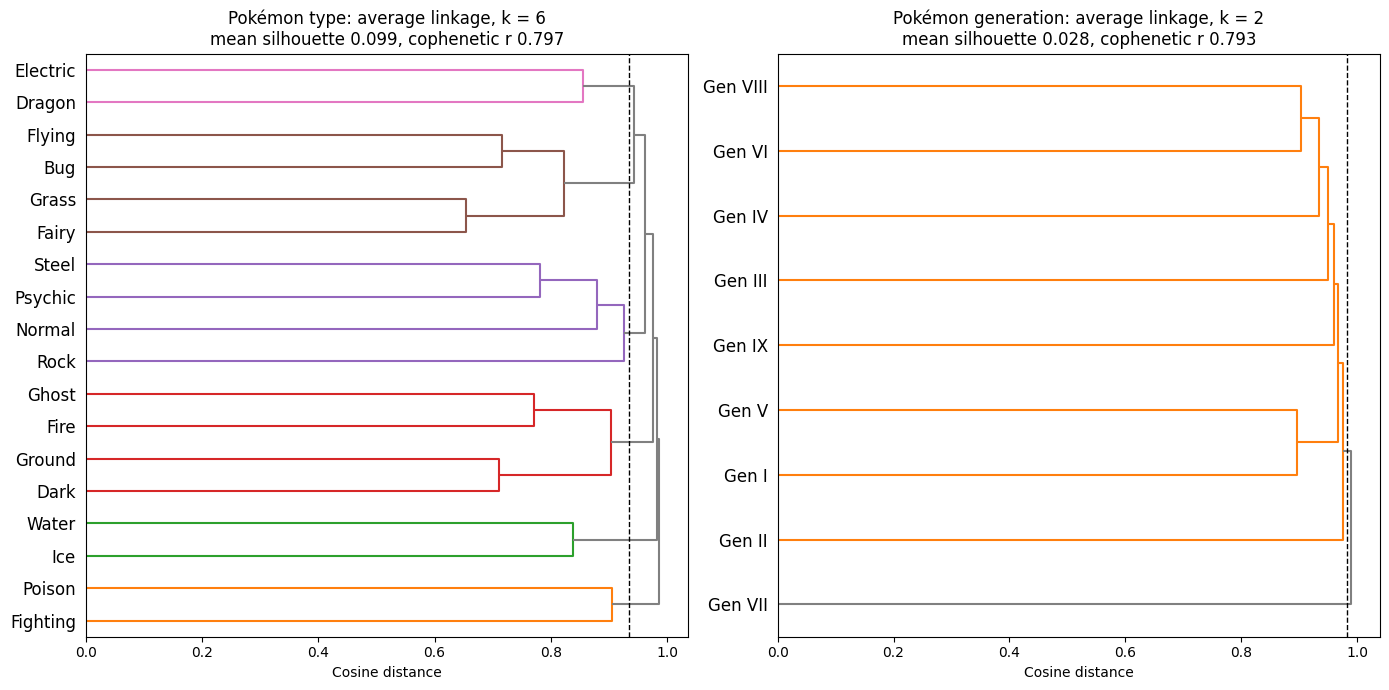

In [16]:
def pretty(label, names):
    if label == "generation":
        return ["Gen " + n.split("-")[1].upper() for n in names]
    return [n.capitalize() for n in names]


fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (label, res) in zip(axes, hca.items()):
    Z, k = res["Z"], res["k"]
    cut = (Z[-k, 2] + Z[-(k - 1), 2]) / 2   # height that leaves exactly k clusters
    dendrogram(Z, labels=pretty(label, mats[label].index), orientation="right",
               color_threshold=cut, above_threshold_color="grey", ax=ax)
    ax.axvline(cut, ls="--", c="k", lw=1)
    ax.set_title(f"Pokémon {label}: {LINKAGE} linkage, k = {k}\n"
                 f"mean silhouette {res['sil'][k]:.3f}, cophenetic r {res['coph']:.3f}")
    ax.set_xlabel("Cosine distance")

plt.tight_layout()
plt.show()